Image Blurring Using Convolution

Applying convolution...

-------------------------------------------------------
  Analysis: Box blur 7×7 — 7×7 kernel
-------------------------------------------------------
  Sharpness loss       : 5.24%
  Mean Squared Error   : 0.003174

-------------------------------------------------------
  Analysis: Gaussian 7×7 σ=2 — 7×7 kernel
-------------------------------------------------------
  Sharpness loss       : 4.73%
  Mean Squared Error   : 0.002660


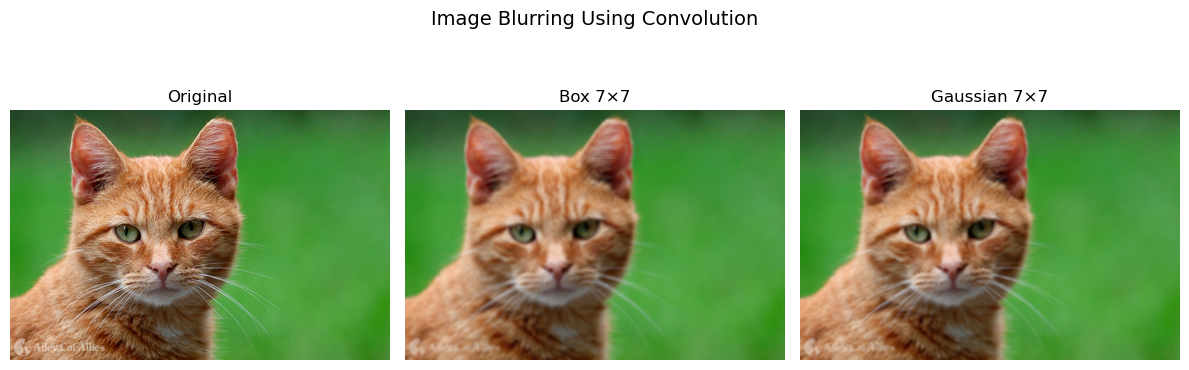

In [8]:
##Image Blurring Using Convolution:
#This module implements image blurring from scratch using core mathematical concepts: matrices, weighted sums, and convolution.

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

#Building Kernels
def box_kernel(size: int) -> np.ndarray:
    assert size % 2 == 1, "Kernel size must be odd."
    kernel = np.ones((size, size), dtype=np.float64)
    return kernel / kernel.sum()


def gaussian_kernel(size: int, sigma: float = None) -> np.ndarray:
    assert size % 2 == 1, "Kernel size must be odd."
    if sigma is None:
        sigma = size / 4.0
    center = size // 2  

    ax = np.arange(size) - center        
    ay = np.arange(size) - center       

    xx, yy = np.meshgrid(ax, ay)

    # Apply the Gaussian formula: exp( -(x² + y²) / (2σ²) )
    kernel = np.exp(-(xx**2 + yy**2) / (2.0 * sigma**2))
    return kernel / kernel.sum()


# SECTION 2: CONVOLUTION

def convolve2d(image: np.ndarray, kernel: np.ndarray) -> np.ndarray:
    k = kernel.shape[0]
    pad = k // 2  
    padded = np.pad(image, pad, mode='edge')

    H, W = image.shape
    output = np.zeros((H, W), dtype=np.float64)

    # Slide the kernel across every pixel position (r, c)
    for r in range(H):
        for c in range(W):
            
            region = padded[r : r + k, c : c + k]
            
            # This is the discrete convolution formula: output[r, c] = Σ_i Σ_j region[i, j] * kernel[i, j]  
            output[r, c] = np.sum(region * kernel)
    return output


def convolve_rgb(image: np.ndarray, kernel: np.ndarray) -> np.ndarray:
    channels = []
    for ch in range(3):
        blurred_ch = convolve2d(image[:, :, ch], kernel)
        channels.append(blurred_ch)

    result = np.stack(channels, axis=2)

    return np.clip(result, 0.0, 1.0)

# SECTION 3: IMAGE LOADING & SAVING

def load_image(path: str) -> np.ndarray:
    img = Image.open(path).convert("RGB")  
    arr = np.array(img, dtype=np.float64)
    return arr / 255.0 


def create_test_image(height: int = 200, width: int = 200) -> np.ndarray:
    img = np.zeros((height, width, 3), dtype=np.float64)

    block = 25
    for r in range(height):
        for c in range(width):
            if ((r // block) + (c // block)) % 2 == 0:
                img[r, c] = [1.0, 1.0, 1.0]   # white
            else:
                img[r, c] = [0.2, 0.2, 0.8]   # blue

    gradient = np.linspace(0, 1, width)
    img[:, :, 0] = np.maximum(img[:, :, 0], gradient[np.newaxis, :] * 0.5)

    return img


# SECTION 4: ANALYSIS & STATISTICS
def standard_deviation(image: np.ndarray) -> float:
    return float(np.std(image))

def mean_squared_error(original: np.ndarray, blurred: np.ndarray) -> float:
    diff = original.astype(np.float64) - blurred.astype(np.float64)
    return float(np.mean(diff ** 2))


def sharpness_loss(original: np.ndarray, blurred: np.ndarray) -> float:
    sigma_orig = standard_deviation(original)
    sigma_blur = standard_deviation(blurred)
    if sigma_orig == 0:
        return 0.0
    return (sigma_orig - sigma_blur) / sigma_orig * 100.0



def run_analysis(original: np.ndarray, blurred: np.ndarray,
                 kernel: np.ndarray, kernel_name: str) -> None:
   
    print("\n" + "-" * 55)
    print(f"  Analysis: {kernel_name} — {kernel.shape[0]}×{kernel.shape[0]} kernel")
    print("-" * 55)
    print(f"  Sharpness loss       : {sharpness_loss(original, blurred):.2f}%")
    print(f"  Mean Squared Error   : {mean_squared_error(original, blurred):.6f}")

# SECTION 5: VISUALISATION

def display_results(original: np.ndarray,
                    results: list[tuple[str, np.ndarray]]) -> None:
    n = len(results) + 1
    fig, axes = plt.subplots(1, n, figsize=(4 * n, 4))
    fig.suptitle("Image Blurring Using Convolution", fontsize=14, y=1.02)

    axes[0].imshow(original)
    axes[0].set_title("Original")
    axes[0].axis("off")

    for i, (label, blurred) in enumerate(results, start=1):
        axes[i].imshow(blurred)
        axes[i].set_title(label)
        axes[i].axis("off")

    plt.tight_layout()
    plt.savefig("blur_results.png", dpi=120, bbox_inches="tight")
    plt.show()

# SECTION 6: MAIN
def main():
    print("Image Blurring Using Convolution")
    image = load_image("FELV-cat.jpg")
    
    
    # Building kernels
    box7   = box_kernel(size=7)
    gauss7 = gaussian_kernel(size=7, sigma=2.0)

    # Applying blur 
    print("\nApplying convolution...")
    blurred_box7   = convolve_rgb(image, box7)
    blurred_gauss7 = convolve_rgb(image, gauss7)

    # Analysis
    run_analysis(image, blurred_box7,   box7,   "Box blur 7×7")
    run_analysis(image, blurred_gauss7, gauss7, "Gaussian 7×7 σ=2")

    # Display 
    display_results(image, [
        ("Box 7×7",        blurred_box7),
        ("Gaussian 7×7",   blurred_gauss7),
    ])


if __name__ == "__main__":
    main()